# Fake Job Postings: EDA and Classic ML Model Comparison

This notebook compares the cleaned feature-engineered dataset (`Data/fake_jobs_cleaned.csv`) with the original Kaggle-style dataset (`Data/fake_job_postings.csv`).

Goals:
- Understand class imbalance and missingness.
- Compare text, categorical, and numeric feature patterns across real and fake postings.
- Run stratified cross-validation on several classic machine learning models.
- Save charts, tables, and model summaries into `results/` for easy project reporting.

In [1]:
# Core setup
from pathlib import Path
import json
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    make_scorer,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler, OneHotEncoder
from sklearn.svm import LinearSVC

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120

DATA_DIR = Path('Data')
RESULTS_DIR = Path('results')
FIG_DIR = RESULTS_DIR / 'figures'
TABLE_DIR = RESULTS_DIR / 'tables'
MODEL_DIR = RESULTS_DIR / 'model_outputs'
for directory in [RESULTS_DIR, FIG_DIR, TABLE_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

DATASETS = {
    'cleaned': DATA_DIR / 'fake_jobs_cleaned.csv',
    'original': DATA_DIR / 'fake_job_postings.csv',
}
TARGET = 'fraudulent'
RANDOM_STATE = 42
N_SPLITS = 5

print('Results will be saved to:', RESULTS_DIR.resolve())

Results will be saved to: C:\Users\patri\OneDrive\Documents\Coding\Python Scripts\ML1\results


In [2]:
# Helper functions
TEXT_COLUMNS = ['title', 'company_profile', 'description', 'requirements', 'benefits']
BASE_CATEGORICAL_COLUMNS = [
    'location', 'department', 'employment_type', 'required_experience',
    'required_education', 'industry', 'function'
]
ID_COLUMNS = ['job_id']


def slugify(value):
    return re.sub(r'[^a-zA-Z0-9_]+', '_', str(value)).strip('_').lower()


def savefig(name):
    path = FIG_DIR / f'{name}.png'
    plt.tight_layout()
    plt.savefig(path, bbox_inches='tight')
    return path


def display_and_save_table(df, name, index=True):
    path = TABLE_DIR / f'{name}.csv'
    df.to_csv(path, index=index)
    display(df)
    print(f'Saved: {path}')


def load_dataset(path):
    df = pd.read_csv(path)
    if TARGET not in df.columns:
        raise ValueError(f'Missing target column: {TARGET}')
    return df


def prepare_features(df):
    X = df.drop(columns=[TARGET]).copy()
    available_text = [c for c in TEXT_COLUMNS if c in X.columns]
    for col in available_text:
        X[col] = X[col].fillna('').astype(str)
    X['text_all'] = X[available_text].agg(' '.join, axis=1) if available_text else ''

    # Keep original text columns out of the structured transformer because text_all contains them.
    drop_cols = [c for c in ID_COLUMNS + available_text if c in X.columns]
    X_model = X.drop(columns=drop_cols, errors='ignore')

    categorical_cols = [c for c in BASE_CATEGORICAL_COLUMNS if c in X_model.columns]
    numeric_cols = [c for c in X_model.columns if c not in categorical_cols + ['text_all']]

    # Some engineered columns may be read as object if they contain unusual values; keep only true numeric columns.
    numeric_cols = [c for c in numeric_cols if pd.api.types.is_numeric_dtype(X_model[c])]
    passthrough_cols = ['text_all'] + categorical_cols + numeric_cols
    X_model = X_model[passthrough_cols]
    return X_model, df[TARGET].astype(int), categorical_cols, numeric_cols


def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=True)


def make_preprocessor(categorical_cols, numeric_cols, use_text=True, use_metadata=True):
    transformers = []
    if use_text:
        transformers.append((
            'text',
            TfidfVectorizer(
                lowercase=True,
                stop_words='english',
                max_features=6000,
                ngram_range=(1, 2),
                min_df=2,
                sublinear_tf=True,
            ),
            'text_all'
        ))
    if use_metadata and categorical_cols:
        transformers.append((
            'categorical',
            Pipeline([
                ('impute', SimpleImputer(strategy='constant', fill_value='missing')),
                ('onehot', make_one_hot_encoder()),
            ]),
            categorical_cols
        ))
    if use_metadata and numeric_cols:
        transformers.append((
            'numeric',
            Pipeline([
                ('impute', SimpleImputer(strategy='median')),
                ('scale', MaxAbsScaler()),
            ]),
            numeric_cols
        ))
    return ColumnTransformer(transformers=transformers, remainder='drop')


def make_models(categorical_cols, numeric_cols):
    text_metadata = make_preprocessor(categorical_cols, numeric_cols, use_text=True, use_metadata=True)
    text_only = make_preprocessor(categorical_cols, numeric_cols, use_text=True, use_metadata=False)
    metadata_only = make_preprocessor(categorical_cols, numeric_cols, use_text=False, use_metadata=True)

    return {
        'Dummy majority baseline': Pipeline([
            ('features', text_metadata),
            ('model', DummyClassifier(strategy='most_frequent')),
        ]),
        'Logistic Regression balanced': Pipeline([
            ('features', text_metadata),
            ('model', LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear', random_state=RANDOM_STATE)),
        ]),
        'Linear SVM balanced': Pipeline([
            ('features', text_metadata),
            ('model', LinearSVC(class_weight='balanced', random_state=RANDOM_STATE)),
        ]),
        'Complement Naive Bayes text only': Pipeline([
            ('features', text_only),
            ('model', ComplementNB(alpha=0.5)),
        ]),
        'Random Forest metadata only': Pipeline([
            ('features', metadata_only),
            ('model', RandomForestClassifier(
                n_estimators=250,
                class_weight='balanced_subsample',
                min_samples_leaf=2,
                n_jobs=-1,
                random_state=RANDOM_STATE,
            )),
        ]),
    }


def positive_precision(y_true, y_pred):
    return precision_score(y_true, y_pred, pos_label=1, zero_division=0)


def positive_recall(y_true, y_pred):
    return recall_score(y_true, y_pred, pos_label=1, zero_division=0)


def positive_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, pos_label=1, zero_division=0)

SCORING = {
    'accuracy': 'accuracy',
    'balanced_accuracy': 'balanced_accuracy',
    'roc_auc': 'roc_auc',
    'average_precision': 'average_precision',
    'precision_fake': make_scorer(positive_precision),
    'recall_fake': make_scorer(positive_recall),
    'f1_fake': make_scorer(positive_f1),
}

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

In [3]:
# Load datasets
raw_datasets = {name: load_dataset(path) for name, path in DATASETS.items()}

summary_rows = []
for name, df in raw_datasets.items():
    counts = df[TARGET].value_counts().sort_index()
    summary_rows.append({
        'dataset': name,
        'rows': len(df),
        'columns': df.shape[1],
        'real_count': int(counts.get(0, 0)),
        'fake_count': int(counts.get(1, 0)),
        'fake_rate': counts.get(1, 0) / len(df),
    })

summary = pd.DataFrame(summary_rows)
display_and_save_table(summary, 'dataset_summary', index=False)

,dataset,rows,columns,real_count,fake_count,fake_rate
0,cleaned,17880,32,17014,866,0.048434
1,original,17880,18,17014,866,0.048434


Saved: results\tables\dataset_summary.csv


## Exploratory Data Analysis

The EDA below is repeated for the cleaned and original datasets. Because fake postings are the minority class, most charts separate real and fake postings rather than only showing overall averages.

### Cleaned Dataset

Shape: (17880, 32)
Columns: job_id, title, location, department, salary_range, company_profile, description, requirements, benefits, telecommuting, has_company_logo, has_questions, employment_type, required_experience, required_education, industry, function, fraudulent, title_length, description_length, requirements_length, company_profile_length, benefits_length, has_salary_range, has_benefits, has_company_profile, has_department, title_word_count, description_word_count, requirements_word_count, company_profile_word_count, benefits_word_count


,count,rate
fraudulent,,
Real,17014,0.951566
Fake,866,0.048434


Saved: results\tables\cleaned_class_balance.csv


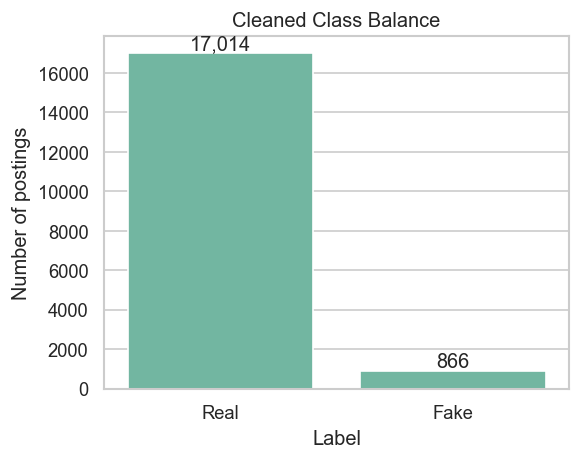

,missing_rate
salary_range,0.839597
benefits,0.403356
company_profile,0.185011
requirements,0.150783
location,0.019351
description,0.000056
job_id,0.000000
department,0.000000
title,0.000000
telecommuting,0.000000


Saved: results\tables\cleaned_missing_rates_top15.csv


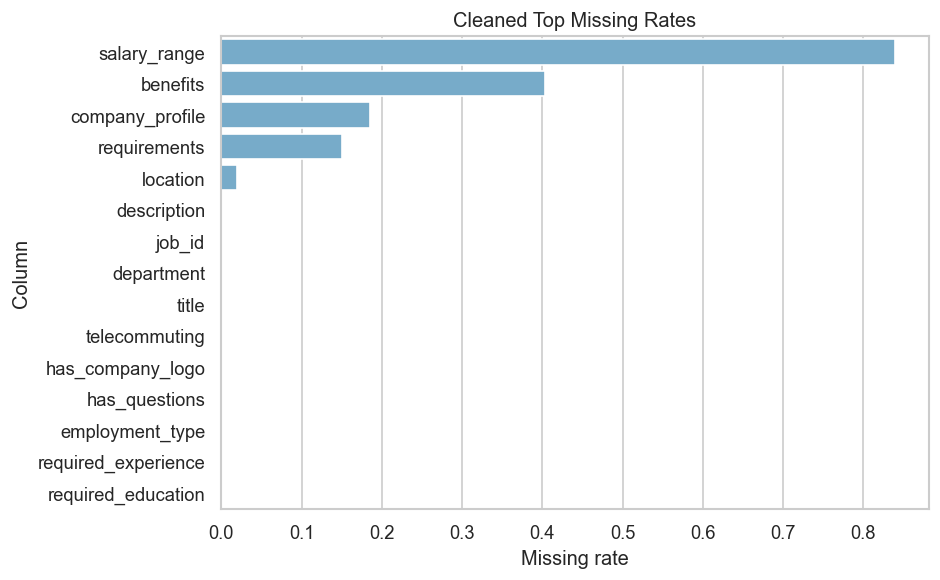

### Original Dataset

Shape: (17880, 18)
Columns: job_id, title, location, department, salary_range, company_profile, description, requirements, benefits, telecommuting, has_company_logo, has_questions, employment_type, required_experience, required_education, industry, function, fraudulent


,count,rate
fraudulent,,
Real,17014,0.951566
Fake,866,0.048434


Saved: results\tables\original_class_balance.csv


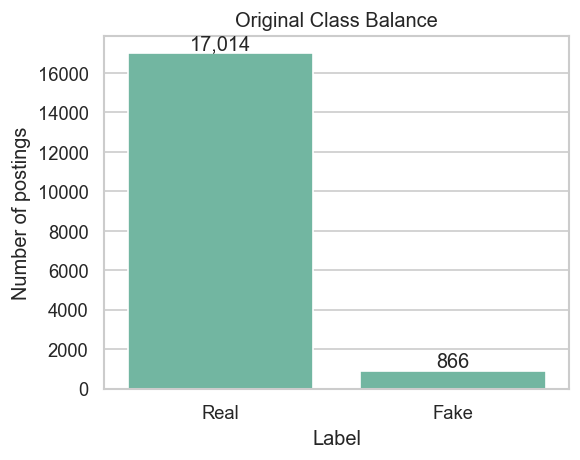

,missing_rate
salary_range,0.839597
department,0.645805
required_education,0.453300
benefits,0.403356
required_experience,0.394295
function,0.361018
industry,0.274217
employment_type,0.194128
company_profile,0.185011
requirements,0.150783


Saved: results\tables\original_missing_rates_top15.csv


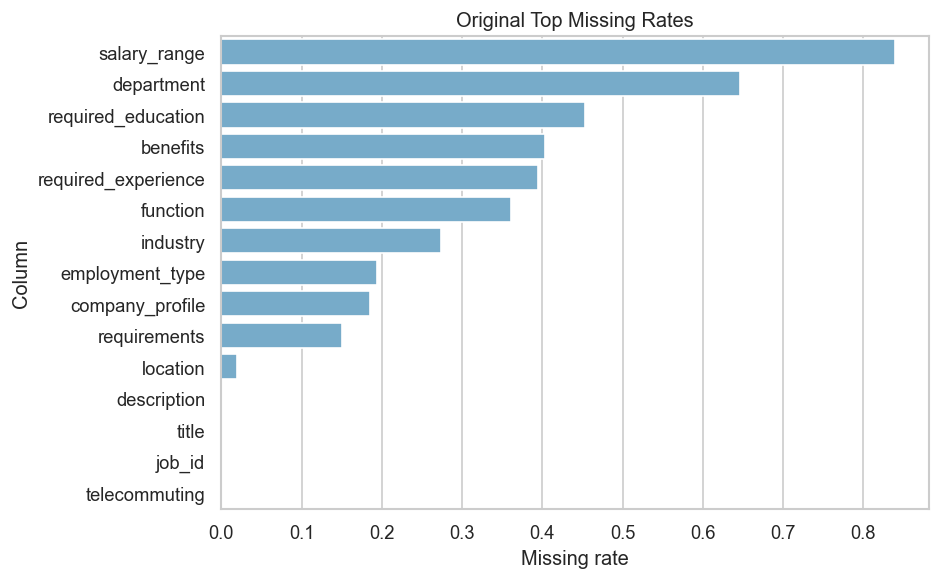

In [4]:
# EDA: class balance and missingness
for name, df in raw_datasets.items():
    display(Markdown(f'### {name.title()} Dataset'))
    print(f'Shape: {df.shape}')
    print('Columns:', ', '.join(df.columns))

    class_counts = df[TARGET].map({0: 'Real', 1: 'Fake'}).value_counts().reindex(['Real', 'Fake'])
    class_rate = (class_counts / class_counts.sum()).rename('rate')
    class_table = pd.DataFrame({'count': class_counts, 'rate': class_rate})
    display_and_save_table(class_table, f'{name}_class_balance')

    plt.figure(figsize=(5, 4))
    ax = sns.barplot(x=class_counts.index, y=class_counts.values)
    ax.set_title(f'{name.title()} Class Balance')
    ax.set_ylabel('Number of postings')
    ax.set_xlabel('Label')
    for i, val in enumerate(class_counts.values):
        ax.text(i, val, f'{val:,}', ha='center', va='bottom')
    savefig(f'{name}_class_balance')
    plt.show()

    missing = df.isna().mean().sort_values(ascending=False).head(15).rename('missing_rate').to_frame()
    display_and_save_table(missing, f'{name}_missing_rates_top15')

    plt.figure(figsize=(8, 5))
    sns.barplot(data=missing.reset_index(), y='index', x='missing_rate', color='#6aaed6')
    plt.title(f'{name.title()} Top Missing Rates')
    plt.xlabel('Missing rate')
    plt.ylabel('Column')
    savefig(f'{name}_missing_rates_top15')
    plt.show()

### Text Length Patterns: Cleaned

mean  median    max
fraudulent field                                 
Fake       benefits          212.2    36.0   2500
           company_profile   230.9     0.0   1422
           description      1154.8   844.5   8578
           requirements      446.0   249.0   4077
           title              30.7    28.0    142
Real       benefits          208.7    47.0   4429
           company_profile   640.8   588.0   6178
           description      1221.2  1027.0  14907
           requirements      597.5   476.5  10864
           title              28.4    25.0    110

Saved: results\tables\cleaned_text_length_summary.csv


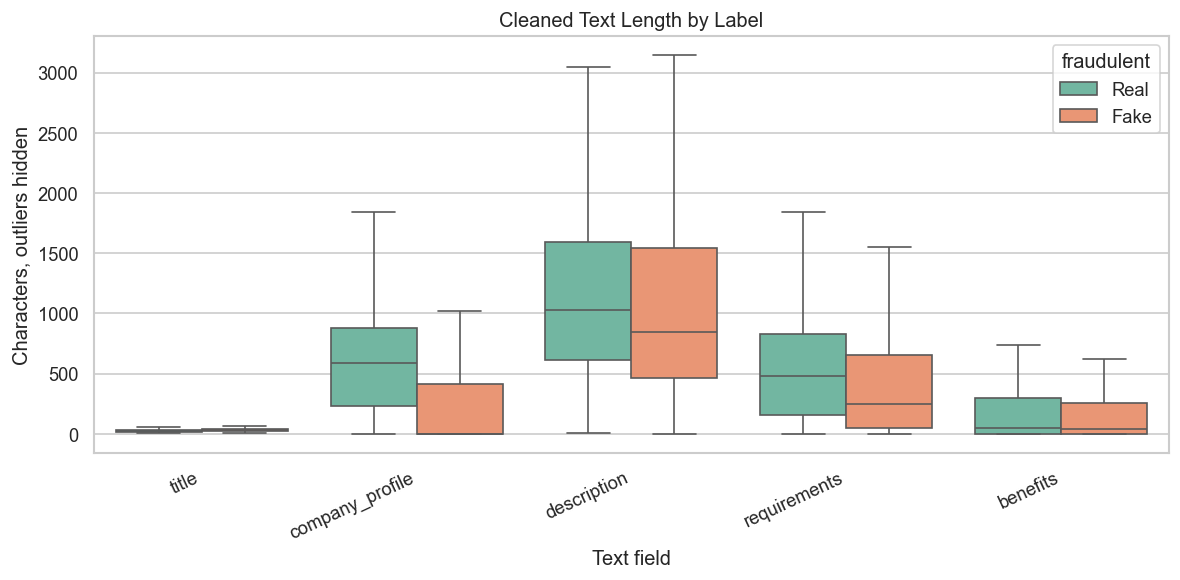

### Text Length Patterns: Original

mean  median    max
fraudulent field                                 
Fake       benefits          212.2    36.0   2500
           company_profile   230.9     0.0   1422
           description      1154.8   844.5   8578
           requirements      446.0   249.0   4077
           title              30.7    28.0    142
Real       benefits          208.7    47.0   4429
           company_profile   640.8   588.0   6178
           description      1221.2  1027.0  14907
           requirements      597.5   476.5  10864
           title              28.4    25.0    110

Saved: results\tables\original_text_length_summary.csv


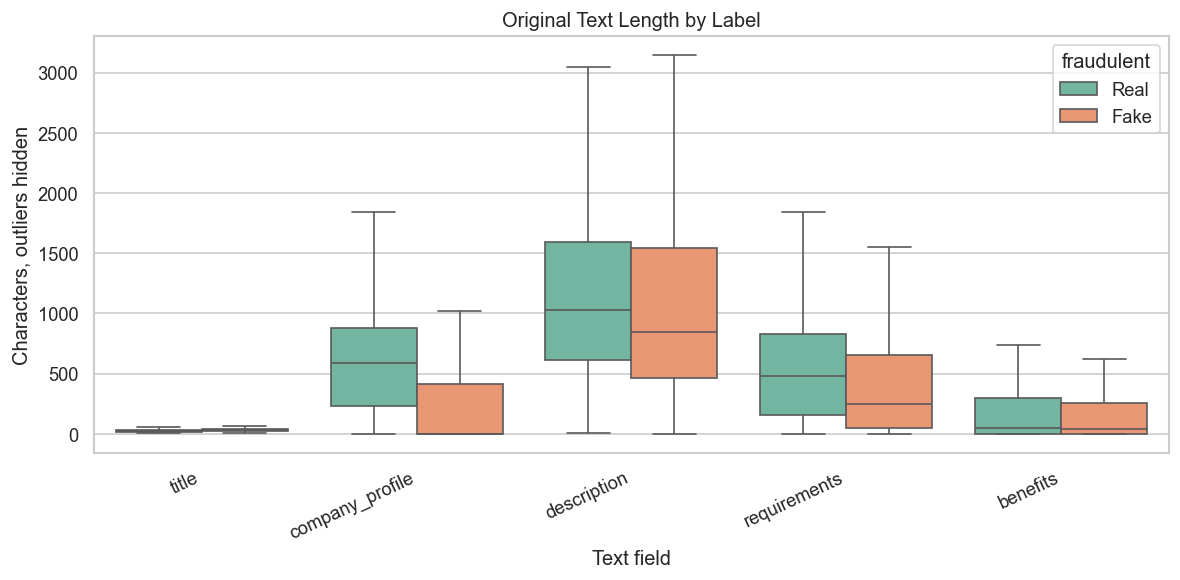

In [5]:
# EDA: text length patterns
for name, df in raw_datasets.items():
    display(Markdown(f'### Text Length Patterns: {name.title()}'))
    text_cols = [c for c in TEXT_COLUMNS if c in df.columns]
    length_frame = pd.DataFrame({
        col: df[col].fillna('').astype(str).str.len()
        for col in text_cols
    })
    length_frame[TARGET] = df[TARGET].map({0: 'Real', 1: 'Fake'})

    melted = length_frame.melt(id_vars=TARGET, var_name='field', value_name='characters')
    length_summary = melted.groupby([TARGET, 'field'])['characters'].agg(['mean', 'median', 'max']).round(1)
    display_and_save_table(length_summary, f'{name}_text_length_summary')

    plt.figure(figsize=(10, 5))
    sns.boxplot(data=melted, x='field', y='characters', hue=TARGET, showfliers=False)
    plt.title(f'{name.title()} Text Length by Label')
    plt.xlabel('Text field')
    plt.ylabel('Characters, outliers hidden')
    plt.xticks(rotation=25, ha='right')
    savefig(f'{name}_text_length_by_label')
    plt.show()

### Categorical Fake Rates: Cleaned

,column,value,count,fake_rate
0,location,"US, CA, San Mateo",46,0.478261
1,location,"AU, NSW, Sydney",82,0.378049
2,location,"US, TX, Houston",269,0.342007
3,location,"US, CA, San Jose",48,0.291667
4,location,"US, CA,",34,0.264706
5,location,"US, CA, Los Angeles",185,0.124324
6,location,"US, NY,",34,0.117647
7,location,"US, WA, Seattle",57,0.105263
8,department,Administrative,30,0.466667
9,department,Customer Service,73,0.191781


Saved: results\tables\cleaned_top_categorical_fake_rates.csv


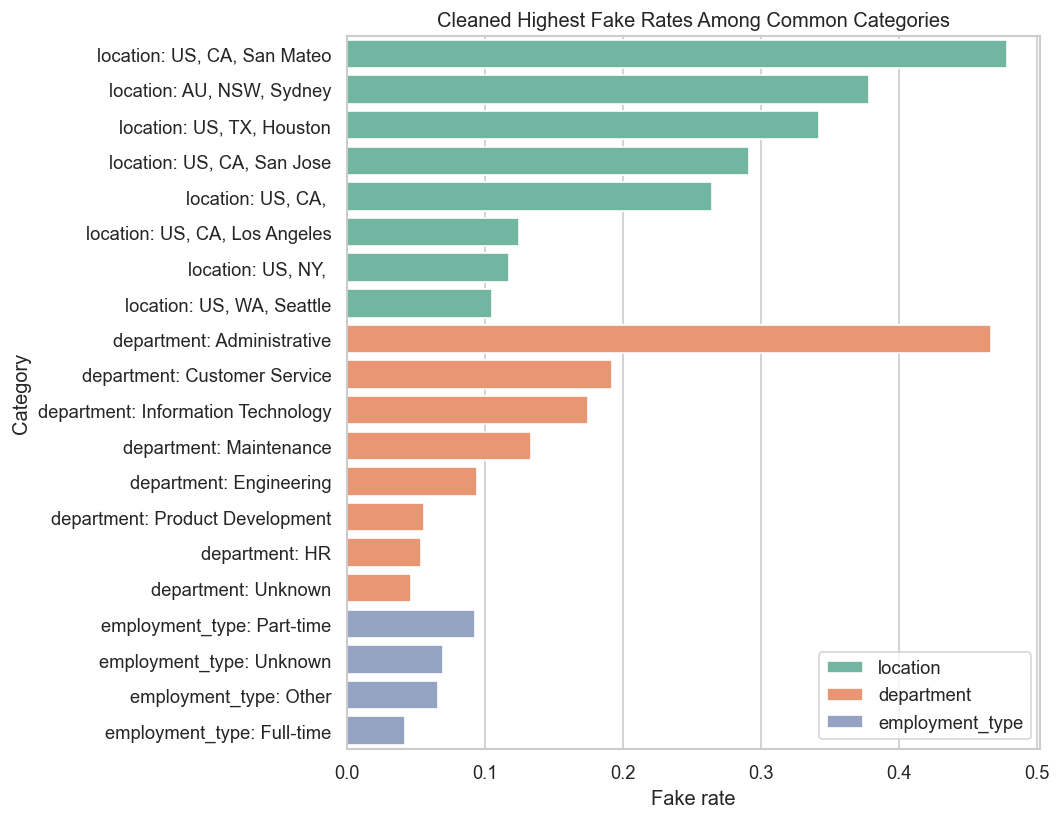

### Categorical Fake Rates: Original

,column,value,count,fake_rate
0,location,"US, CA, San Mateo",46,0.478261
1,location,"AU, NSW, Sydney",82,0.378049
2,location,"US, TX, Houston",269,0.342007
3,location,"US, CA, San Jose",48,0.291667
4,location,"US, CA,",34,0.264706
5,location,"US, CA, Los Angeles",185,0.124324
6,location,"US, NY,",34,0.117647
7,location,"US, WA, Seattle",57,0.105263
8,department,Administrative,30,0.466667
9,department,Customer Service,73,0.191781


Saved: results\tables\original_top_categorical_fake_rates.csv


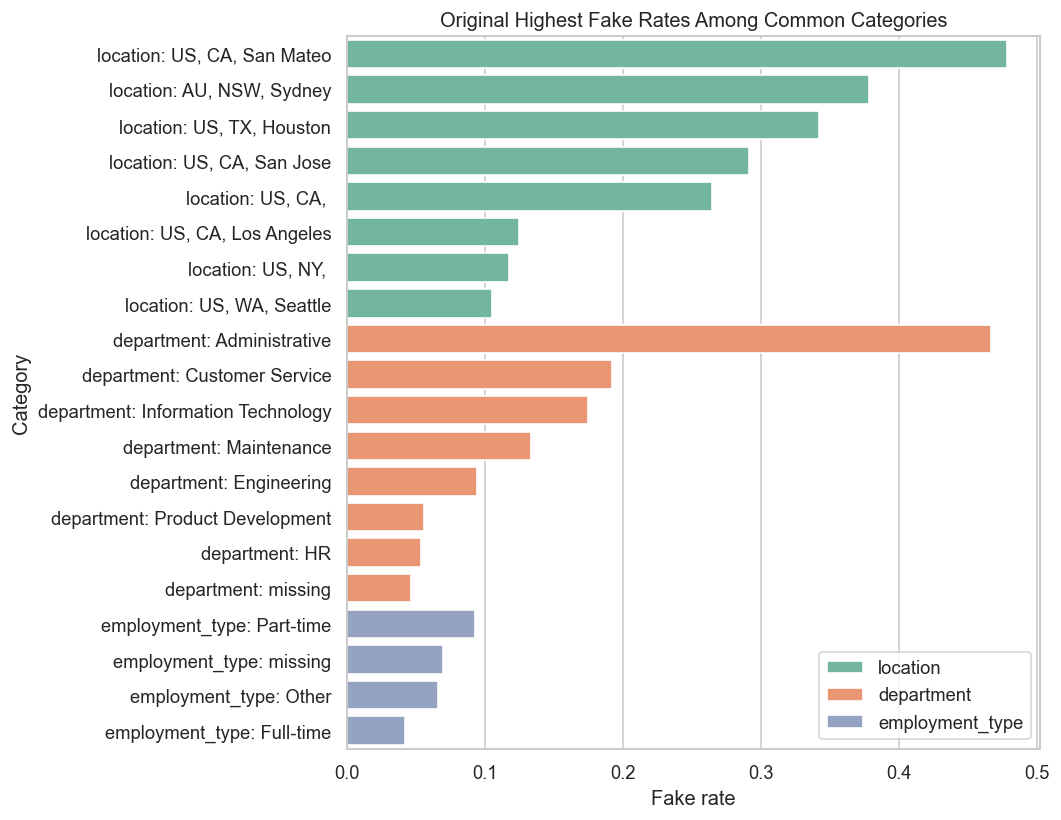

In [6]:
# EDA: categorical fields with the highest fake rates
for name, df in raw_datasets.items():
    display(Markdown(f'### Categorical Fake Rates: {name.title()}'))
    cat_cols = [c for c in BASE_CATEGORICAL_COLUMNS if c in df.columns]
    frames = []
    for col in cat_cols:
        temp = df[[col, TARGET]].copy()
        temp[col] = temp[col].fillna('missing').astype(str)
        grouped = temp.groupby(col)[TARGET].agg(['count', 'mean']).rename(columns={'mean': 'fake_rate'})
        grouped = grouped[grouped['count'] >= 30].sort_values('fake_rate', ascending=False).head(8)
        grouped.insert(0, 'column', col)
        grouped.insert(1, 'value', grouped.index)
        frames.append(grouped.reset_index(drop=True))
    cat_rates = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    display_and_save_table(cat_rates, f'{name}_top_categorical_fake_rates', index=False)

    if not cat_rates.empty:
        plot_data = cat_rates.head(20).copy()
        plot_data['label'] = plot_data['column'] + ': ' + plot_data['value'].str.slice(0, 35)
        plt.figure(figsize=(9, 7))
        sns.barplot(data=plot_data, y='label', x='fake_rate', hue='column', dodge=False)
        plt.title(f'{name.title()} Highest Fake Rates Among Common Categories')
        plt.xlabel('Fake rate')
        plt.ylabel('Category')
        plt.legend(loc='lower right')
        savefig(f'{name}_top_categorical_fake_rates')
        plt.show()

## Cross-Validated Model Comparison

The models below are intentionally classic and explainable enough for an introductory machine learning project:

- Dummy majority baseline: shows why accuracy is not enough.
- Logistic Regression with class weights: strong baseline for sparse text features.
- Linear SVM with class weights: another strong linear text classifier.
- Complement Naive Bayes: simple text-only baseline often used for imbalanced text classification.
- Random Forest on metadata only: tests how far non-text structured fields can go.

The main ranking metric is `average_precision` because it focuses on finding the rare fake class across decision thresholds.

In [7]:
# Run cross-validation comparisons
all_results = []
fitted_feature_info = []

for dataset_name, df in raw_datasets.items():
    display(Markdown(f'### Cross-validation: {dataset_name.title()}'))
    X, y, categorical_cols, numeric_cols = prepare_features(df)
    models = make_models(categorical_cols, numeric_cols)
    fitted_feature_info.append({
        'dataset': dataset_name,
        'categorical_features': ', '.join(categorical_cols),
        'numeric_features': ', '.join(numeric_cols),
        'positive_class_rate': y.mean(),
    })
    print('Categorical features:', categorical_cols)
    print('Numeric features:', numeric_cols)

    for model_name, estimator in models.items():
        print(f'Running {dataset_name} | {model_name}...')
        scores = cross_validate(
            estimator,
            X,
            y,
            cv=cv,
            scoring=SCORING,
            n_jobs=-1,
            return_train_score=False,
            error_score='raise',
        )
        row = {'dataset': dataset_name, 'model': model_name}
        for metric_name in SCORING:
            values = scores[f'test_{metric_name}']
            row[f'{metric_name}_mean'] = values.mean()
            row[f'{metric_name}_std'] = values.std()
        all_results.append(row)

cv_results = pd.DataFrame(all_results)
metric_cols = [c for c in cv_results.columns if c.endswith('_mean')]
cv_results_sorted = cv_results.sort_values(['dataset', 'average_precision_mean'], ascending=[True, False])
display_and_save_table(cv_results_sorted.round(4), 'cv_model_comparison', index=False)

feature_info = pd.DataFrame(fitted_feature_info)
display_and_save_table(feature_info, 'model_feature_columns', index=False)

### Cross-validation: Cleaned

Categorical features: ['location', 'department', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']
Numeric features: ['telecommuting', 'has_company_logo', 'has_questions', 'title_length', 'description_length', 'requirements_length', 'company_profile_length', 'benefits_length', 'has_salary_range', 'has_benefits', 'has_company_profile', 'has_department', 'title_word_count', 'description_word_count', 'requirements_word_count', 'company_profile_word_count', 'benefits_word_count']
Running cleaned | Dummy majority baseline...


Running cleaned | Logistic Regression balanced...


Running cleaned | Linear SVM balanced...


Running cleaned | Complement Naive Bayes text only...


...

Running original | Random Forest metadata only...


,dataset,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std,precision_fake_mean,precision_fake_std,recall_fake_mean,recall_fake_std,f1_fake_mean,f1_fake_std
2,cleaned,Linear SVM balanced,0.9858,0.0007,0.9164,0.0093,0.9890,0.0019,0.9140,0.0147,0.8636,0.0095,0.8395,0.0189,0.8512,0.0086
1,cleaned,Logistic Regression balanced,0.9706,0.0031,0.9325,0.0080,0.9884,0.0018,0.8810,0.0182,0.6430,0.0271,0.8903,0.0148,0.7464,0.0211
3,cleaned,Complement Naive Bayes text only,0.8261,0.0111,0.8714,0.0090,0.9539,0.0077,0.7387,0.0398,0.2084,0.0103,0.9215,0.0177,0.3398,0.0138
4,cleaned,Random Forest metadata only,0.9145,0.0046,0.8899,0.0096,0.9651,0.0034,0.7145,0.0245,0.3469,0.0142,0.8626,0.0179,0.4947,0.0160
0,cleaned,Dummy majority baseline,0.9516,0.0001,0.5000,0.0000,0.5000,0.0000,0.0484,0.0001,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
7,original,Linear SVM balanced,0.9858,0.0004,0.9147,0.0073,0.9880,0.0026,0.9128,0.0131,0.8665,0.0146,0.8361,0.0155,0.8508,0.0045
6,original,Logistic Regression balanced,0.9730,0.0030,0.9338,0.0057,0.9876,0.0025,0.8850,0.0175,0.6666,0.0309,0.8903,0.0107,0.7620,0.0212
8,original,Complement Naive Bayes text only,0.8261,0.0111,0.8714,0.0090,0.9539,0.0077,0.7387,0.0398,0.2084,0.0103,0.9215,0.0177,0.3398,0.0138
9,original,Random Forest metadata only,0.9199,0.0021,0.8845,0.0158,0.9569,0.0045,0.7143,0.0352,0.3604,0.0091,0.8453,0.0321,0.5053,0.0140
5,original,Dummy majority baseline,0.9516,0.0001,0.5000,0.0000,0.5000,0.0000,0.0484,0.0001,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


Saved: results\tables\cv_model_comparison.csv


,dataset,categorical_features,numeric_features,positive_class_rate
0,cleaned,"location, department, employment_type, require...","telecommuting, has_company_logo, has_questions...",0.048434
1,original,"location, department, employment_type, require...","telecommuting, has_company_logo, has_questions",0.048434


Saved: results\tables\model_feature_columns.csv


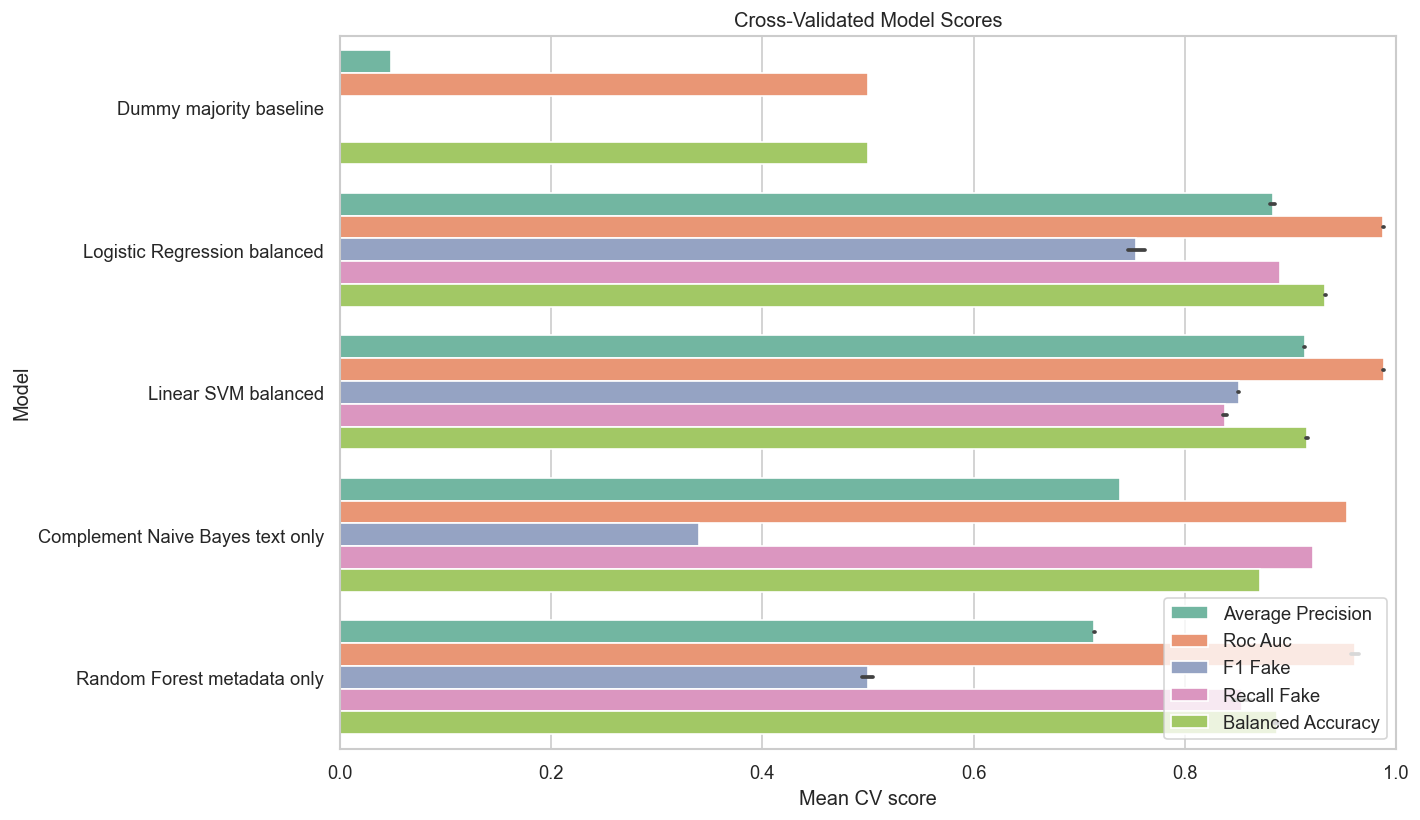

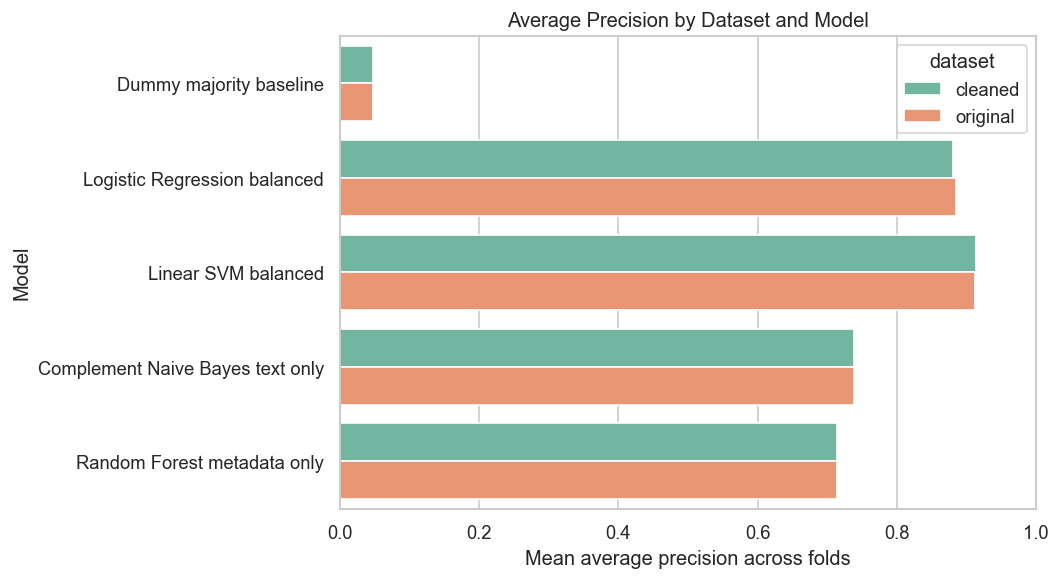

In [8]:
# Plot CV results
plot_metrics = ['average_precision_mean', 'roc_auc_mean', 'f1_fake_mean', 'recall_fake_mean', 'balanced_accuracy_mean']
plot_data = cv_results.melt(
    id_vars=['dataset', 'model'],
    value_vars=plot_metrics,
    var_name='metric',
    value_name='score'
)
plot_data['metric'] = plot_data['metric'].str.replace('_mean', '', regex=False).str.replace('_', ' ').str.title()

plt.figure(figsize=(12, 7))
sns.barplot(data=plot_data, x='score', y='model', hue='metric')
plt.title('Cross-Validated Model Scores')
plt.xlabel('Mean CV score')
plt.ylabel('Model')
plt.xlim(0, 1)
plt.legend(loc='lower right')
savefig('cv_model_scores_all_metrics')
plt.show()

plt.figure(figsize=(9, 5))
sns.barplot(data=cv_results, x='average_precision_mean', y='model', hue='dataset')
plt.title('Average Precision by Dataset and Model')
plt.xlabel('Mean average precision across folds')
plt.ylabel('Model')
plt.xlim(0, 1)
savefig('average_precision_by_dataset_model')
plt.show()

### Best Model by Average Precision: Cleaned

Linear SVM balanced


,dataset,model,precision,recall,f1-score,support
Real,cleaned,Linear SVM balanced,0.9918,0.9932,0.9925,17014.0000
Fake,cleaned,Linear SVM balanced,0.8634,0.8395,0.8513,866.0000
accuracy,cleaned,Linear SVM balanced,0.9858,0.9858,0.9858,0.9858
macro avg,cleaned,Linear SVM balanced,0.9276,0.9164,0.9219,17880.0000
weighted avg,cleaned,Linear SVM balanced,0.9856,0.9858,0.9857,17880.0000


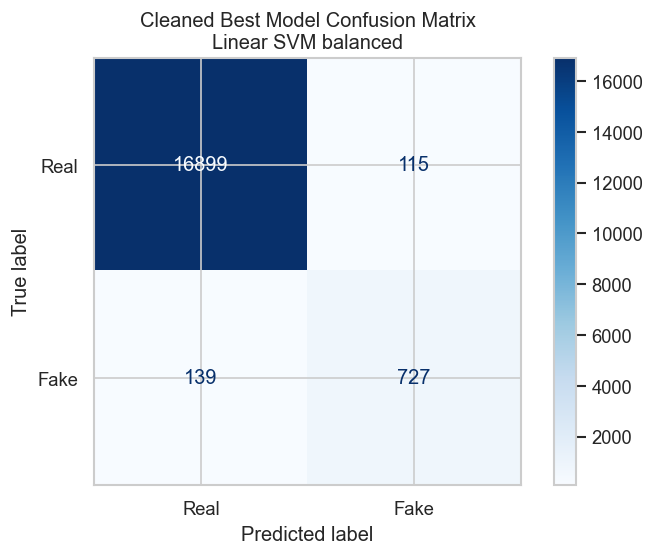

### Best Model by Average Precision: Original

Linear SVM balanced


,dataset,model,precision,recall,f1-score,support
Real,original,Linear SVM balanced,0.9917,0.9934,0.9925,17014.0000
Fake,original,Linear SVM balanced,0.8660,0.8360,0.8508,866.0000
accuracy,original,Linear SVM balanced,0.9858,0.9858,0.9858,0.9858
macro avg,original,Linear SVM balanced,0.9288,0.9147,0.9217,17880.0000
weighted avg,original,Linear SVM balanced,0.9856,0.9858,0.9857,17880.0000


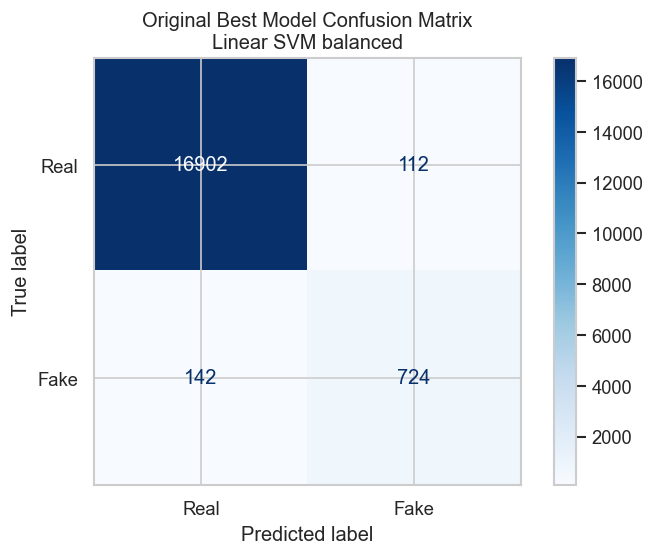

,class,dataset,model,precision,recall,f1-score,support
0,Real,cleaned,Linear SVM balanced,0.9918,0.9932,0.9925,17014.0000
1,Fake,cleaned,Linear SVM balanced,0.8634,0.8395,0.8513,866.0000
2,accuracy,cleaned,Linear SVM balanced,0.9858,0.9858,0.9858,0.9858
3,macro avg,cleaned,Linear SVM balanced,0.9276,0.9164,0.9219,17880.0000
4,weighted avg,cleaned,Linear SVM balanced,0.9856,0.9858,0.9857,17880.0000
5,Real,original,Linear SVM balanced,0.9917,0.9934,0.9925,17014.0000
6,Fake,original,Linear SVM balanced,0.8660,0.8360,0.8508,866.0000
7,accuracy,original,Linear SVM balanced,0.9858,0.9858,0.9858,0.9858
8,macro avg,original,Linear SVM balanced,0.9288,0.9147,0.9217,17880.0000
9,weighted avg,original,Linear SVM balanced,0.9856,0.9858,0.9857,17880.0000


Saved: results\tables\best_model_classification_reports.csv


In [9]:
# Confusion matrices and classification reports for the best model per dataset
best_rows = cv_results.sort_values('average_precision_mean', ascending=False).groupby('dataset').head(1)
reports = []

for _, best in best_rows.iterrows():
    dataset_name = best['dataset']
    model_name = best['model']
    df = raw_datasets[dataset_name]
    X, y, categorical_cols, numeric_cols = prepare_features(df)
    estimator = make_models(categorical_cols, numeric_cols)[model_name]

    display(Markdown(f'### Best Model by Average Precision: {dataset_name.title()}'))
    print(model_name)

    y_pred = cross_val_predict(estimator, X, y, cv=cv, n_jobs=-1, method='predict')
    cm = confusion_matrix(y, y_pred, labels=[0, 1])
    report_dict = classification_report(y, y_pred, labels=[0, 1], target_names=['Real', 'Fake'], output_dict=True, zero_division=0)
    report_df = pd.DataFrame(report_dict).T
    report_df.insert(0, 'dataset', dataset_name)
    report_df.insert(1, 'model', model_name)
    reports.append(report_df.reset_index(names='class'))

    display(report_df.round(4))
    report_df.to_csv(MODEL_DIR / f'{dataset_name}_best_model_classification_report.csv')

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'Fake'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'{dataset_name.title()} Best Model Confusion Matrix\n{model_name}')
    savefig(f'{dataset_name}_best_model_confusion_matrix')
    plt.show()

classification_reports = pd.concat(reports, ignore_index=True)
display_and_save_table(classification_reports.round(4), 'best_model_classification_reports', index=False)

In [10]:
# Simple project-direction summary generated from results
top_by_dataset = cv_results.sort_values('average_precision_mean', ascending=False).groupby('dataset').head(1)
comparison = top_by_dataset[['dataset', 'model', 'average_precision_mean', 'roc_auc_mean', 'f1_fake_mean', 'recall_fake_mean', 'precision_fake_mean']].round(4)
display_and_save_table(comparison, 'top_model_by_dataset', index=False)

cleaned_top = comparison[comparison['dataset'] == 'cleaned'].iloc[0]
original_top = comparison[comparison['dataset'] == 'original'].iloc[0]

print('Suggested path forward:')
print(f"1. Use average precision as the main comparison metric because the fake class is only about {summary.loc[0, 'fake_rate']:.1%} of the data.")
print(f"2. Treat {cleaned_top['model']} on the cleaned dataset as the current leading baseline if interpretability and performance are both acceptable.")
print(f"3. Compare cleaned vs original results directly: cleaned AP={cleaned_top['average_precision_mean']}, original AP={original_top['average_precision_mean']}.")
print('4. For the class project, a strong next step is error analysis: inspect false positives and false negatives, then explain which words/metadata patterns drive the model.')
print('5. Avoid presenting accuracy as the headline metric; the dummy baseline can look high simply because most postings are real.')

,dataset,model,average_precision_mean,roc_auc_mean,f1_fake_mean,recall_fake_mean,precision_fake_mean
2,cleaned,Linear SVM balanced,0.9140,0.989,0.8512,0.8395,0.8636
7,original,Linear SVM balanced,0.9128,0.988,0.8508,0.8361,0.8665


Saved: results\tables\top_model_by_dataset.csv
Suggested path forward:
1. Use average precision as the main comparison metric because the fake class is only about 4.8% of the data.
2. Treat Linear SVM balanced on the cleaned dataset as the current leading baseline if interpretability and performance are both acceptable.
3. Compare cleaned vs original results directly: cleaned AP=0.914, original AP=0.9128.
4. For the class project, a strong next step is error analysis: inspect false positives and false negatives, then explain which words/metadata patterns drive the model.
5. Avoid presenting accuracy as the headline metric; the dummy baseline can look high simply because most postings are real.


## Notes for the Final Project

Possible project angle:

Build an interpretable fake job posting detector using classic machine learning, then explain how imbalance changes model evaluation. The cleaned dataset can be framed as the feature-engineered version, while the original dataset is the raw baseline. A good final deliverable would include:

- Class imbalance discussion and why accuracy is misleading.
- EDA findings about missing fields, text length, and high-risk categories.
- Cross-validation table comparing classic models.
- Confusion matrix and classification report for the best model.
- Error analysis of false positives and false negatives.
- A short discussion of ethical limitations: this should support human review, not automatically reject job posts.